# Proyek Klasifikasi Gambar: [Animal Image Classification]

## **Sumber Dataset**
https://www.kaggle.com/datasets/borhanitrash/animal-image-classification-dataset


- **Nama:** [Muhammad Varel Arifianta]
- **Email:** [mhdvarels@gmail.com]
- **ID Dicoding:** [varelsaurus]

## Import Semua Packages/Library yang Digunakan

In [4]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

In [6]:
!rm -r Animal_Image_Classification

rm: cannot remove 'Animal_Image_Classification': No such file or directory


In [7]:
!gdown --id 1XaseGzRsGAeXZxn-ddQHWnPd6wxrZtA9

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1XaseGzRsGAeXZxn-ddQHWnPd6wxrZtA9
From (redirected): https://drive.google.com/uc?id=1XaseGzRsGAeXZxn-ddQHWnPd6wxrZtA9&confirm=t&uuid=31f85987-5810-47fb-a511-6990998bb69d
To: /content/Animal Image Classification.zip
100% 40.2M/40.2M [00:01<00:00, 37.6MB/s]


In [8]:
!unzip "Animal Image Classification.zip" -d Animal_Image_Classification

Archive:  Animal Image Classification.zip
  inflating: Animal_Image_Classification/Animals/cats/0_0001.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0002.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0003.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0004.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0005.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0006.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0007.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0008.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0009.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0010.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0011.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0012.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0013.jpg  
  inflating: Animal_Image_Classification/Animals/cats/0_0014.jpg  
  inflating: Animal_

In [9]:
# Direktori awal
cat_dir = "Animal_Image_Classification/Animals/cats"
dogs_dir = "Animal_Image_Classification/Animals/dogs"
snake_dir = "Animal_Image_Classification/Animals/snakes"

# Direktori baru untuk dataset gabungan
combined_dir = "Animal_Image_Classification/dataset"

# Buat direktori baru untuk dataset gabungan, bersihkan jika sudah ada
if os.path.exists(combined_dir):
    shutil.rmtree(combined_dir)
os.makedirs(combined_dir, exist_ok=True)

# Salin folder 'cats', 'dogs', and 'snakes' dari direktori awal ke direktori gabungan
shutil.copytree(cat_dir, os.path.join(combined_dir, "cats"))
shutil.copytree(dogs_dir, os.path.join(combined_dir, "dogs"))
shutil.copytree(snake_dir, os.path.join(combined_dir, "snakes"))

'Animal_Image_Classification/dataset/snakes'

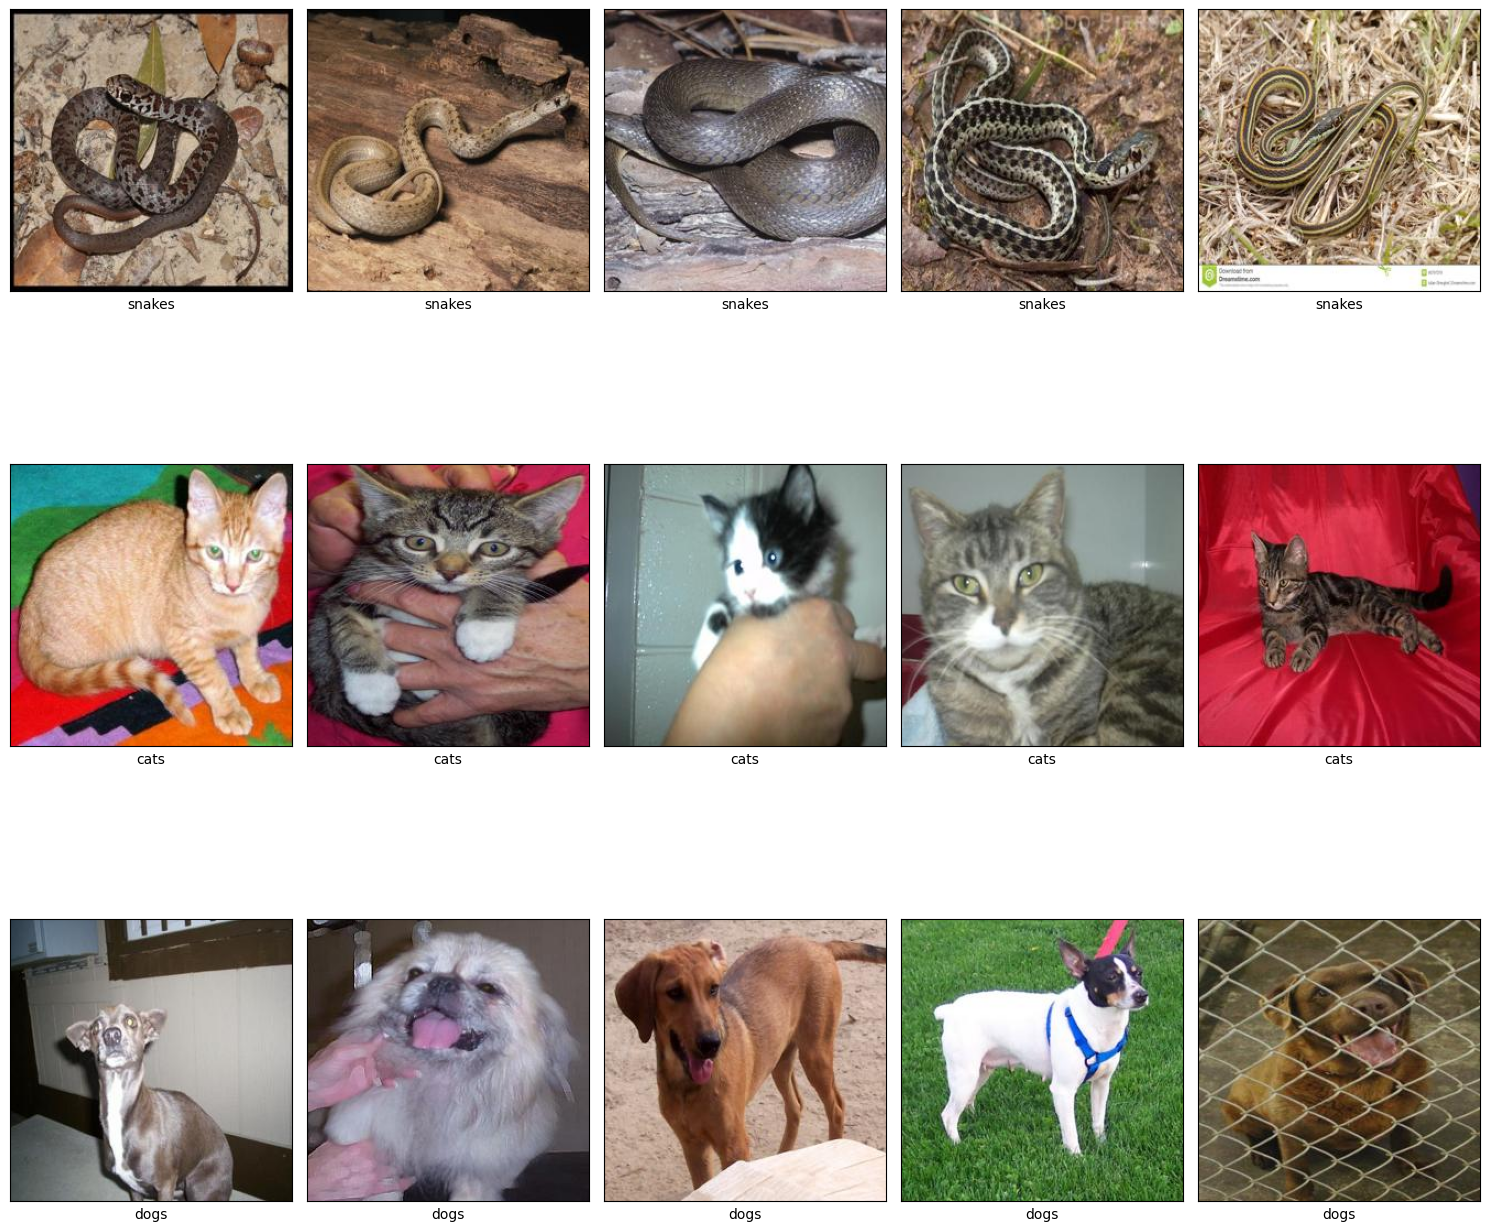

In [10]:
# Membuat array untuk menyimpan gambar
animal_image = {}

# Tentukan path sumber
path = "Animal_Image_Classification/"
path_sub = os.path.join(path, "dataset") # Correctly define path_sub before the loop

for class_name in os.listdir(path_sub):
    class_path = os.path.join(path_sub, class_name)
    if os.path.isdir(class_path):
        animal_image[class_name] = os.listdir(class_path)

# Menampilkan secara acak 5 gambah dibawah setiap kelas dari data
fig, axs = plt.subplots(len(animal_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(animal_image.keys()):
    images = np.random.choice(animal_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

### Data Preprocessing

#### Split Dataset

In [11]:
# Memanggil variabel yang menampul folder dataset gambar
mypath = 'Animal_Image_Classification/dataset'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan
df = pd.DataFrame({'path':full_path,'label':labels,'file_name':file_name})
# Melihat jumlah data gambar pada masing-masing
df.groupby(['label']).size()

,0
label,
cats,1000
dogs,1000
snakes,1000


In [12]:
# Variabel yang digunakan pada pemisahan data
X = df['path']
y = df['label']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Menyatukan kedalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'label':y_train, 'set':'train'})
df_ts = pd.DataFrame({'path':X_test,'label':y_test, "set": "test"})
# Print
print('train size', len(df_tr))
print('test size', len(df_ts))
# Gabungkan DataFrame df_tr dan df_ts
df_all = pd.concat([df_tr, df_ts], ignore_index=True)

train size 2400
test size 600


In [14]:
# Split df_tr menjadi train dan validation
df_train, df_val = train_test_split(df_tr, test_size=0.2, random_state=42, stratify=df_tr['label'])

# Print ukuran dataset
print('train size:', len(df_train))
print('validation size:', len(df_val))
print('test size:', len(df_ts))

train size: 1920
validation size: 480
test size: 600


In [15]:
#Update df_all dengan set validation
df_val['set'] = 'validation'
df_all = pd.concat([df_train, df_val, df_ts], ignore_index=True)

In [16]:
# Parameter gambar
img_shape = (224, 224, 3)
BATCH_SIZE = 32

# Augmentasi data menggunakan ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
# Generate data dari dataframe
train_generator = train_datagen.flow_from_dataframe(
    df_train,
    x_col='path',
    y_col='label',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    df_val,
    x_col='path',
    y_col='label',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    df_ts,
    x_col='path',
    y_col='label',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1920 validated image filenames belonging to 3 classes.
Found 480 validated image filenames belonging to 3 classes.
Found 600 validated image filenames belonging to 3 classes.


## Modelling

In [34]:
base_model = MobileNetV2(input_shape=img_shape, include_top=False, weights='imagenet')
base_model.trainable = False
img_shape = (224, 224, 3)
model = Sequential([
    base_model,
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,004,035 (11.46 MB)

 Trainable params: 746,051 (2.85 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // 32,
    callbacks=[early_stopping]
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 37s 456ms/step - accuracy: 0.7817 - loss: 0.6257 - val_accuracy: 0.9792 - val_loss: 0.0590
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 378ms/step - accuracy: 0.9456 - loss: 0.1563 - val_accuracy: 0.9812 - val_loss: 0.0779
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 391ms/step - accuracy: 0.9583 - loss: 0.1262 - val_accuracy: 0.9792 - val_loss: 0.0842
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 396ms/step - accuracy: 0.9697 - loss: 0.0887 - val_accuracy: 0.9750 - val_loss: 0.1083
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 388ms/step - accuracy: 0.9744 - loss: 0.0758 - val_accuracy: 0.9833 - val_loss: 0.0721
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 378ms/step - accuracy: 0.9690 - loss: 0.0721 - val_accuracy: 0.9854 - val_loss: 0.0641


## Evaluasi dan Visualisasi

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 599ms/step - accuracy: 0.9900 - loss: 0.0414
Test accuracy: 99.00%


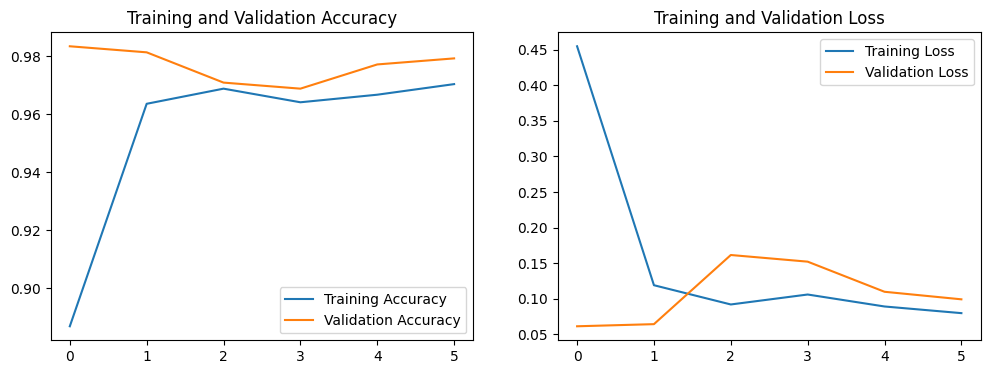

In [20]:
# Evaluasi pada test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc * 100:.2f}%')


# Plot akurasi dan loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

## Konversi Model

In [42]:
# SavedModel
model.export('animal_model_saved')

# TF-Lite
# Convert the SavedModel to TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('animal_model_saved')
tflite_model = converter.convert()
with open('animal_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at 'animal_model_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_316')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135649162942928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162950224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162950992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162950416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162949648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162950800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162950032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162949840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162952336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135649162948688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13564916

In [43]:
# TFJS (memerlukan instalasi tensorflowjs jika belum)
!pip install tensorflowjs
import tensorflowjs as tfjs
tfjs.converters.save_keras_model(model, 'animal_model_tfjs')

failed to lookup keras version from the file,
    this is likely a weight only file


In [44]:
!pip freeze > requirements.txt

In [45]:
!zip -r saved_model.zip animal_model_saved/
!zip -r tfjs_model.zip animal_model_tfjs/

  adding: animal_model_saved/ (stored 0%)
  adding: animal_model_saved/variables/ (stored 0%)
  adding: animal_model_saved/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: animal_model_saved/variables/variables.index (deflated 78%)
  adding: animal_model_saved/assets/ (stored 0%)
  adding: animal_model_saved/saved_model.pb (deflated 91%)
  adding: animal_model_saved/fingerprint.pb (stored 0%)
  adding: animal_model_tfjs/ (stored 0%)
  adding: animal_model_tfjs/group1-shard3of3.bin (deflated 7%)
  adding: animal_model_tfjs/model.json (deflated 97%)
  adding: animal_model_tfjs/group1-shard1of3.bin (deflated 8%)
  adding: animal_model_tfjs/group1-shard2of3.bin (deflated 7%)


## Inference (Optional)